# Selective Breast-Cancer Classification with Calibrated Probabilities

## Project overview

A conventional classifier produces a prediction for every observation, including cases where its confidence is low. In a safety-sensitive setting, a more responsible system can automatically classify clear cases while deferring uncertain cases for expert review.

This project develops a calibrated breast-cancer classifier and evaluates a **selective prediction policy** with three possible outcomes:

- automatically classify as benign;
- automatically classify as malignant;
- defer the uncertain case for review.

## Main objectives

1. Compare logistic regression and random forest models.
2. Evaluate ranking performance and probability calibration.
3. Select a decision threshold using asymmetric error costs.
4. Examine the trade-off between automatic coverage and error rate.
5. Identify uncertain cases that should be reviewed.
6. Interpret which measurements influence model predictions.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss, log_loss,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    precision_recall_curve, accuracy_score, recall_score,
    precision_score, f1_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 42

## 1. Load and inspect the dataset

The Wisconsin Diagnostic Breast Cancer dataset contains numerical measurements extracted from breast-mass images.

The original target uses:

- `0` for malignant;
- `1` for benign.

For this project, the target is reversed so that **malignant is the positive class (`1`)**. This makes sensitivity and false-negative calculations easier to interpret.

In [2]:
dataset = load_breast_cancer(as_frame=True)
X = dataset.data.copy()
y = (dataset.target == 0).astype(int)
y.name = "malignant"

summary = pd.Series({
    "Observations": len(X),
    "Features": X.shape[1],
    "Malignant cases": int(y.sum()),
    "Benign cases": int((y == 0).sum()),
    "Missing values": int(X.isna().sum().sum()),
    "Duplicate rows": int(X.duplicated().sum())
}, name="value").to_frame()

display(summary)
display(X.head())
display(X.describe().T.round(2))

,value
Observations,569
Features,30
Malignant cases,212
Benign cases,357
Missing values,0
Duplicate rows,0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
mean concavity,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
mean symmetry,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
mean fractal dimension,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


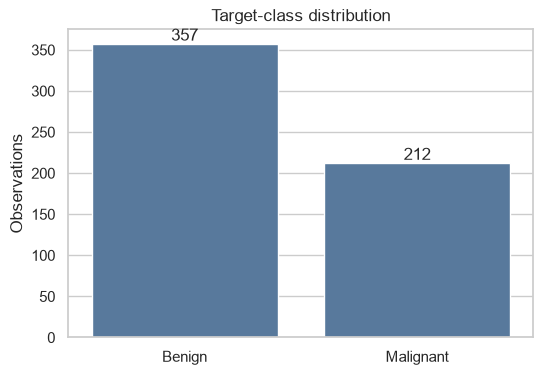

malignant
Benign       62.74
Malignant    37.26
Name: count, dtype: float64


In [3]:
class_counts = y.map({0: "Benign", 1: "Malignant"}).value_counts()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, color="#4c78a8")
ax.bar_label(ax.containers[0])
plt.title("Target-class distribution")
plt.ylabel("Observations")
plt.xlabel("")
plt.show()

print((class_counts / len(y) * 100).round(2))

### Initial dataset observations

The dataset contains **569 observations and 30 numerical features**. There are 357 benign cases and 212 malignant cases, corresponding to **62.74% benign and 37.26% malignant**.

This is a moderate class imbalance rather than an extreme one. Stratified splitting and class-weighted models are still appropriate because malignant cases are the more safety-critical positive class.

There are no missing values or duplicated rows, so no imputation or duplicate removal is required.

The features have substantially different numerical scales. For example, mean radius ranges from 6.98 to 28.11, mean texture from 9.71 to 39.28, and mean area from 143.5 to 2,501. Worst area reaches 4,254. Standardisation is therefore necessary for logistic regression so that large-scale variables do not dominate its optimisation.

## 2. Exploratory feature analysis

Correlation with the binary target provides an initial indication of which measurements differ most between malignant and benign observations.

Correlation does not establish causality, and highly correlated measurements may describe the same underlying tumour characteristic.

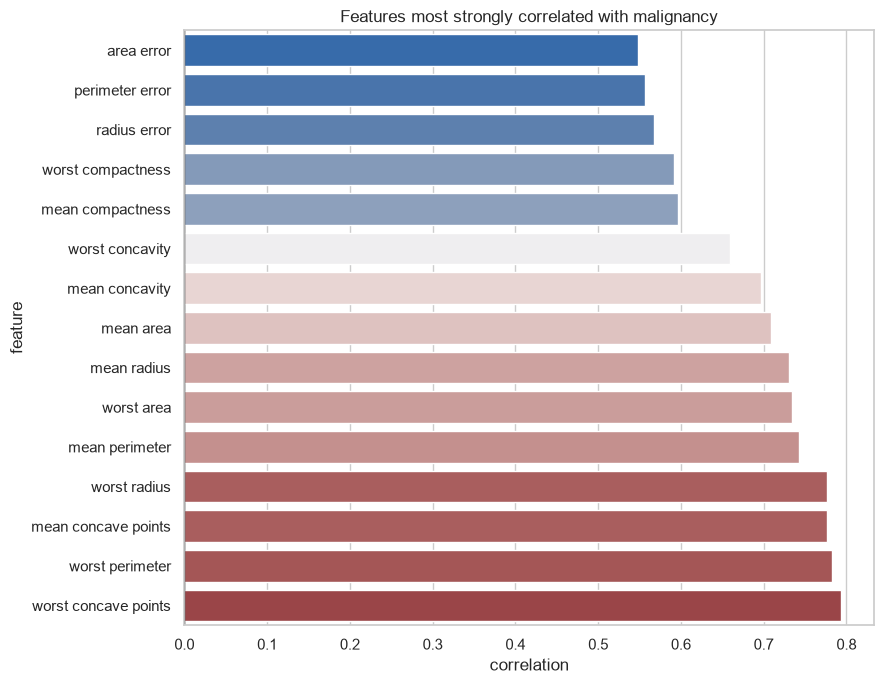

,feature,correlation
0,area error,0.548236
1,perimeter error,0.556141
2,radius error,0.567134
3,worst compactness,0.590998
4,mean compactness,0.596534
5,worst concavity,0.659610
6,mean concavity,0.696360
7,mean area,0.708984
8,mean radius,0.730029
9,worst area,0.733825


In [4]:
target_correlations = X.corrwith(y).dropna()
top_features = target_correlations.abs().nlargest(15).index

correlation_df = (
    target_correlations.loc[top_features]
    .sort_values()
    .rename("correlation")
    .reset_index()
    .rename(columns={"index": "feature"})
)

plt.figure(figsize=(9, 7))
sns.barplot(data=correlation_df, x="correlation", y="feature", hue="correlation",
            palette="vlag", legend=False)
plt.axvline(0, color="black", linewidth=1)
plt.title("Features most strongly correlated with malignancy")
plt.tight_layout()
plt.show()

correlation_df

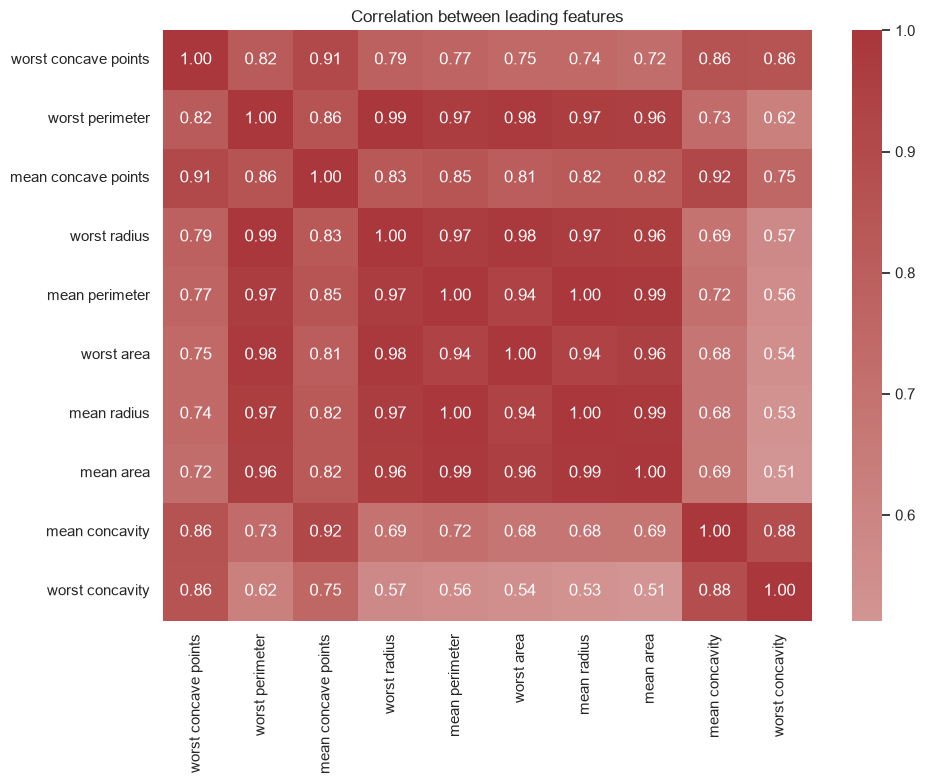

In [5]:
top_ten = target_correlations.abs().nlargest(10).index

plt.figure(figsize=(10, 8))
sns.heatmap(X[top_ten].corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation between leading features")
plt.tight_layout()
plt.show()

### Exploratory findings

All 15 leading correlations are positive because malignant cases were encoded as 1. Higher values for size, boundary, and concavity-related measurements are therefore associated with malignancy in this dataset.

The strongest target correlations are:

- worst concave points: **0.794**;
- worst perimeter: **0.783**;
- mean concave points: **0.777**;
- worst radius: **0.776**;
- mean perimeter: **0.743**;
- worst area: **0.734**;
- mean radius: **0.730**.

The leading predictors are also highly correlated with one another. Mean radius and mean perimeter have an almost perfect correlation, while mean perimeter and mean area correlate at approximately 0.99. Worst radius and worst perimeter also correlate at approximately 0.99. Mean concavity and mean concave points correlate at 0.92.

This multicollinearity indicates that several features describe closely related tumour characteristics. It can distribute importance across related variables and make individual model coefficients less stable. Correlation also describes association rather than proving that any measurement directly causes malignancy.

In [6]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame([
    {"split": "Training", "observations": len(y_train), "malignant_pct": 100 * y_train.mean()},
    {"split": "Validation", "observations": len(y_val), "malignant_pct": 100 * y_val.mean()},
    {"split": "Test", "observations": len(y_test), "malignant_pct": 100 * y_test.mean()}
])

split_summary.round(2)

,split,observations,malignant_pct
0,Training,341,37.24
1,Validation,114,37.72
2,Test,114,36.84


## 4. Model training and probability calibration

Two model families are compared:

1. **Logistic regression** 
2. **Random forest** 

Hyperparameters are selected using five-fold stratified cross-validation and ROC-AUC.

The selected estimators are then calibrated using cross-validated sigmoid calibration. Calibration is important because selective prediction and cost-based thresholding rely on meaningful probabilities, not only class rankings.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_specs = {
    "Logistic regression": (
        Pipeline([
            ("scale", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE
            ))
        ]),
        {"model__C": [0.01, 0.1, 1, 10]}
    ),
    "Random forest": (
        RandomForestClassifier(
            n_estimators=300, class_weight="balanced",
            n_jobs=-1, random_state=RANDOM_STATE
        ),
        {"max_depth": [None, 4, 8], "min_samples_leaf": [1, 3, 6]}
    )
}

In [8]:
def make_calibrator(estimator):
    try:
        return CalibratedClassifierCV(estimator=estimator, method="sigmoid", cv=5)
    except TypeError:
        return CalibratedClassifierCV(base_estimator=estimator, method="sigmoid", cv=5)

calibrated_models, result_rows = {}, []

for name, (estimator, param_grid) in model_specs.items():
    search = GridSearchCV(estimator, param_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
    search.fit(X_train, y_train)

    calibrated = make_calibrator(search.best_estimator_)
    calibrated.fit(X_train, y_train)
    probability = calibrated.predict_proba(X_val)[:, 1]

    calibrated_models[name] = calibrated
    result_rows.append({
        "model": name,
        "best_parameters": str(search.best_params_),
        "cv_roc_auc": search.best_score_,
        "validation_roc_auc": roc_auc_score(y_val, probability),
        "validation_pr_auc": average_precision_score(y_val, probability),
        "brier_score": brier_score_loss(y_val, probability),
        "log_loss": log_loss(y_val, probability)
    })

In [9]:
baseline = DummyClassifier(strategy="prior").fit(X_train, y_train)
baseline_probability = baseline.predict_proba(X_val)[:, 1]

result_rows.append({
    "model": "Prior baseline",
    "best_parameters": "None",
    "cv_roc_auc": np.nan,
    "validation_roc_auc": roc_auc_score(y_val, baseline_probability),
    "validation_pr_auc": average_precision_score(y_val, baseline_probability),
    "brier_score": brier_score_loss(y_val, baseline_probability),
    "log_loss": log_loss(y_val, baseline_probability)
})

model_results_df = pd.DataFrame(result_rows)
candidate_results = model_results_df[model_results_df["model"] != "Prior baseline"]
selected_name = candidate_results.sort_values(
    ["brier_score", "validation_roc_auc"], ascending=[True, False]
).iloc[0]["model"]

selected_model = calibrated_models[selected_name]

display(model_results_df.round(4))
print("Selected model:", selected_name)

,model,best_parameters,cv_roc_auc,validation_roc_auc,validation_pr_auc,brier_score,log_loss
0,Logistic regression,{'model__C': 1},0.9941,0.9961,0.9949,0.0263,0.1202
1,Random forest,"{'max_depth': None, 'min_samples_leaf': 1}",0.9875,0.9925,0.9908,0.0271,0.1182
2,Prior baseline,None,NaN,0.5000,0.3772,0.2349,0.6627


Selected model: Logistic regression


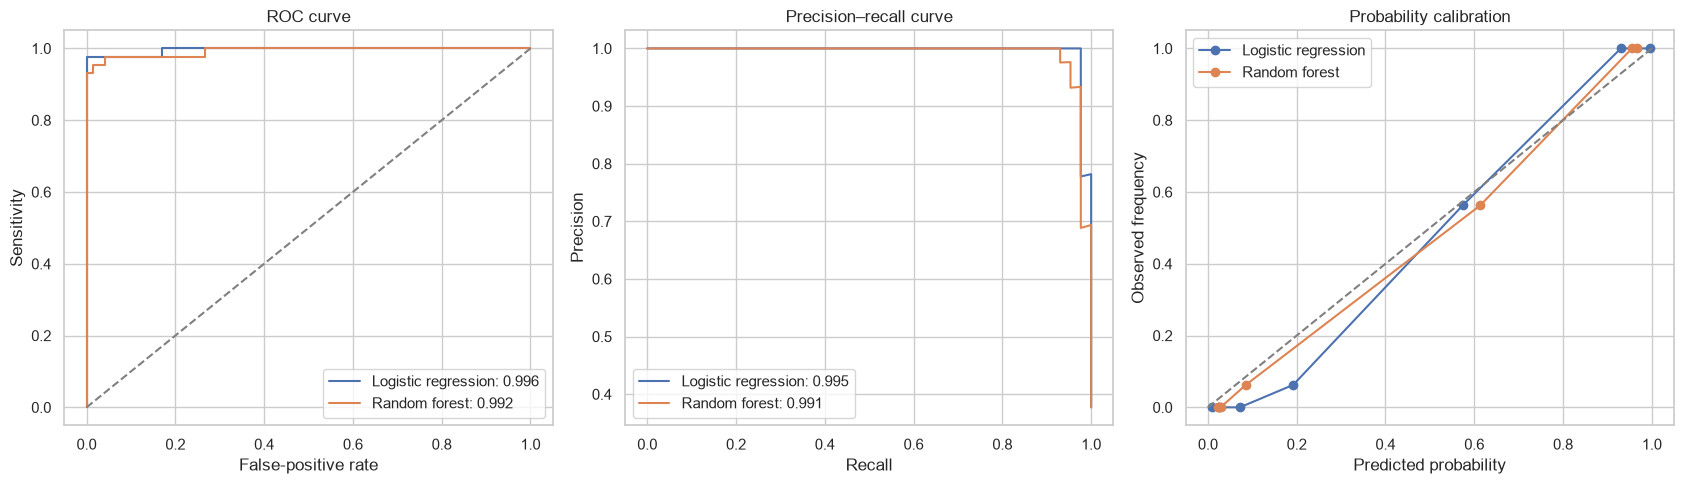

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for name, model in calibrated_models.items():
    probability = model.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, probability)
    precision, recall, _ = precision_recall_curve(y_val, probability)
    observed, predicted = calibration_curve(y_val, probability, n_bins=7, strategy="quantile")

    axes[0].plot(fpr, tpr, label=f"{name}: {roc_auc_score(y_val, probability):.3f}")
    axes[1].plot(recall, precision, label=f"{name}: {average_precision_score(y_val, probability):.3f}")
    axes[2].plot(predicted, observed, marker="o", label=name)

axes[0].plot([0, 1], [0, 1], "--", color="grey")
axes[2].plot([0, 1], [0, 1], "--", color="grey")

axes[0].set(title="ROC curve", xlabel="False-positive rate", ylabel="Sensitivity")
axes[1].set(title="Precision–recall curve", xlabel="Recall", ylabel="Precision")
axes[2].set(title="Probability calibration", xlabel="Predicted probability", ylabel="Observed frequency")

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

### Model comparison 

Both calibrated models substantially outperform the prior-probability baseline.

Logistic regression achieved:

- cross-validated ROC-AUC: **0.9941**;
- validation ROC-AUC: **0.9961**;
- validation PR-AUC: **0.9949**;
- Brier score: **0.0263**;
- log loss: **0.1202**.

Random forest achieved a validation ROC-AUC of 0.9925, PR-AUC of 0.9908, Brier score of 0.0271, and log loss of 0.1182. The prior baseline achieved a ROC-AUC of 0.50, PR-AUC of 0.3772, and a much worse Brier score of 0.2349.

Logistic regression was selected because it produced the lowest Brier score and the highest validation ROC-AUC and PR-AUC. Random forest achieved a slightly lower log loss, but its overall validation performance was marginally weaker.

The calibration curves are generally close to the ideal diagonal, particularly for moderate and high probabilities. Some deviation remains in the lower-probability bins, which is expected given the small validation set. Overall, the calibrated probabilities are sufficiently reliable for the following threshold and deferral experiments.

## 5. Cost-sensitive threshold selection

A probability threshold of 0.50 is conventional but may not reflect the consequences of different errors.

For this experiment:

- a false negative receives an illustrative cost of 10;
- a false positive receives a cost of 1.

The values are not clinical cost estimates. They simply represent the assumption that incorrectly classifying a malignant case as benign is substantially more serious.

The threshold is selected using validation data only.

In [11]:
validation_probability = selected_model.predict_proba(X_val)[:, 1]

def build_threshold_table(y_true, probability, false_negative_cost=10, false_positive_cost=1):
    rows = []

    for threshold in np.linspace(0.05, 0.95, 91):
        prediction = (probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()

        rows.append({
            "threshold": threshold,
            "sensitivity": tp / (tp + fn),
            "specificity": tn / (tn + fp),
            "false_positives": fp,
            "false_negatives": fn,
            "total_cost": false_negative_cost * fn + false_positive_cost * fp
        })

    return pd.DataFrame(rows)

threshold_df = build_threshold_table(y_val, validation_probability)
selected_threshold_row = threshold_df.sort_values(
    ["total_cost", "false_negatives", "false_positives"]
).iloc[0]

selected_threshold = float(selected_threshold_row["threshold"])
selected_threshold_row.to_frame("selected_operating_point").round(3)

,selected_operating_point
threshold,0.510
sensitivity,0.977
specificity,1.000
false_positives,0.000
false_negatives,1.000
total_cost,10.000


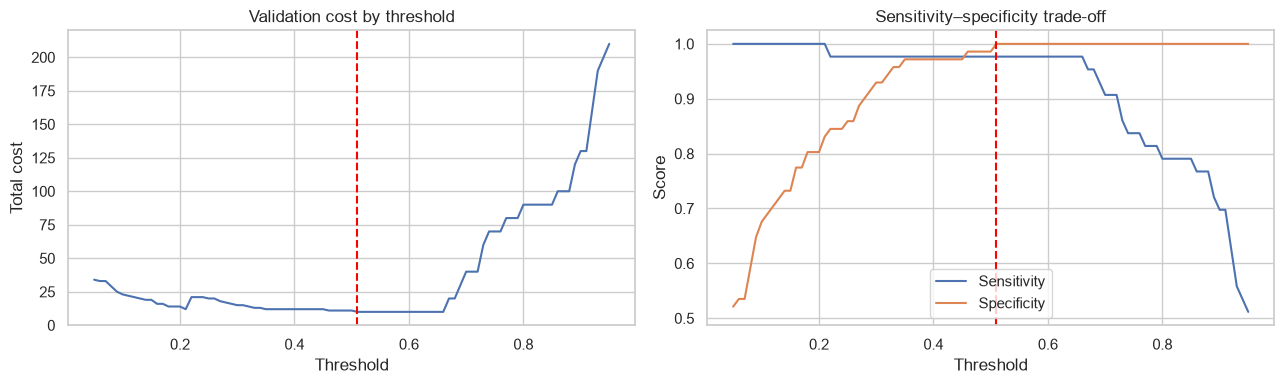

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(threshold_df["threshold"], threshold_df["total_cost"])
axes[0].axvline(selected_threshold, color="red", linestyle="--")
axes[0].set(title="Validation cost by threshold", xlabel="Threshold", ylabel="Total cost")

axes[1].plot(threshold_df["threshold"], threshold_df["sensitivity"], label="Sensitivity")
axes[1].plot(threshold_df["threshold"], threshold_df["specificity"], label="Specificity")
axes[1].axvline(selected_threshold, color="red", linestyle="--")
axes[1].set(title="Sensitivity–specificity trade-off", xlabel="Threshold", ylabel="Score")
axes[1].legend()

plt.tight_layout()
plt.show()

,operating_point,threshold,accuracy,sensitivity,specificity,precision,f1,false_positives,false_negatives,illustrative_cost
0,Default threshold,0.50,0.974,0.929,1.0,1.0,0.963,0,3,30
1,Cost-sensitive threshold,0.51,0.974,0.929,1.0,1.0,0.963,0,3,30


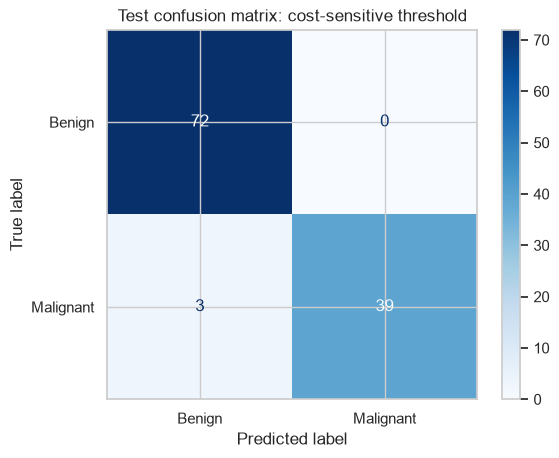

In [13]:
test_probability = selected_model.predict_proba(X_test)[:, 1]

def classification_metrics(y_true, probability, threshold, label):
    prediction = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()

    return {
        "operating_point": label,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, prediction),
        "sensitivity": recall_score(y_true, prediction),
        "specificity": tn / (tn + fp),
        "precision": precision_score(y_true, prediction),
        "f1": f1_score(y_true, prediction),
        "false_positives": fp,
        "false_negatives": fn,
        "illustrative_cost": fp + 10 * fn
    }

test_operating_points = pd.DataFrame([
    classification_metrics(y_test, test_probability, 0.50, "Default threshold"),
    classification_metrics(y_test, test_probability, selected_threshold, "Cost-sensitive threshold")
])

display(test_operating_points.round(3))

cost_prediction = (test_probability >= selected_threshold).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, cost_prediction, display_labels=["Benign", "Malignant"], cmap="Blues"
)
plt.title("Test confusion matrix: cost-sensitive threshold")
plt.show()

### Threshold selection 

The validation procedure selected a probability threshold of **0.51**, which is almost identical to the conventional threshold of 0.50. On validation data, this threshold produced 97.7% sensitivity, 100% specificity, no false positives, and one false negative.

On the untouched test set, thresholds of 0.50 and 0.51 produced exactly the same predictions:

- accuracy: **97.4%**;
- sensitivity: **92.9%**;
- specificity: **100%**;
- precision: **100%**;
- F1-score: **0.963**;
- false positives: **0**;
- false negatives: **3**;
- illustrative cost: **30**.

The model correctly classified all 72 benign test cases and 39 of the 42 malignant cases. However, three malignant cases were incorrectly classified as benign.

Therefore, cost-sensitive threshold tuning did not improve test performance in this particular split. The selected threshold was too close to 0.50 to change any test predictions, showing that validation-based threshold improvements do not always transfer to unseen data.

## 6. Selective prediction with a deferral region

The cost-sensitive threshold still forces a decision for every case.

Selective prediction introduces two boundaries:

- probability below the lower boundary → automatically benign;
- probability above the upper boundary → automatically malignant;
- probability between the boundaries → defer for review.

Increasing the margin around the decision threshold reduces automatic coverage but may improve accuracy among automatically classified cases.

In [14]:
def selective_metrics(y_true, probability, centre, margin):
    lower = max(0, centre - margin)
    upper = min(1, centre + margin)

    accepted = (probability <= lower) | (probability >= upper)
    prediction = (probability >= upper).astype(int)

    accepted_y = np.asarray(y_true)[accepted]
    accepted_prediction = prediction[accepted]
    tn, fp, fn, tp = confusion_matrix(
        accepted_y, accepted_prediction, labels=[0, 1]
    ).ravel()

    return {
        "margin": margin,
        "lower_threshold": lower,
        "upper_threshold": upper,
        "coverage": accepted.mean(),
        "deferred_cases": int((~accepted).sum()),
        "accepted_error_rate": np.mean(accepted_prediction != accepted_y),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "accepted_sensitivity": tp / (tp + fn) if tp + fn else np.nan,
        "deferred_malignant": int(np.asarray(y_true)[~accepted].sum())
    }

maximum_margin = max(0.01, min(selected_threshold, 1 - selected_threshold) - 0.01)
margins = np.linspace(0, maximum_margin, 30)

validation_selective_df = pd.DataFrame([
    selective_metrics(y_val, validation_probability, selected_threshold, margin)
    for margin in margins
])

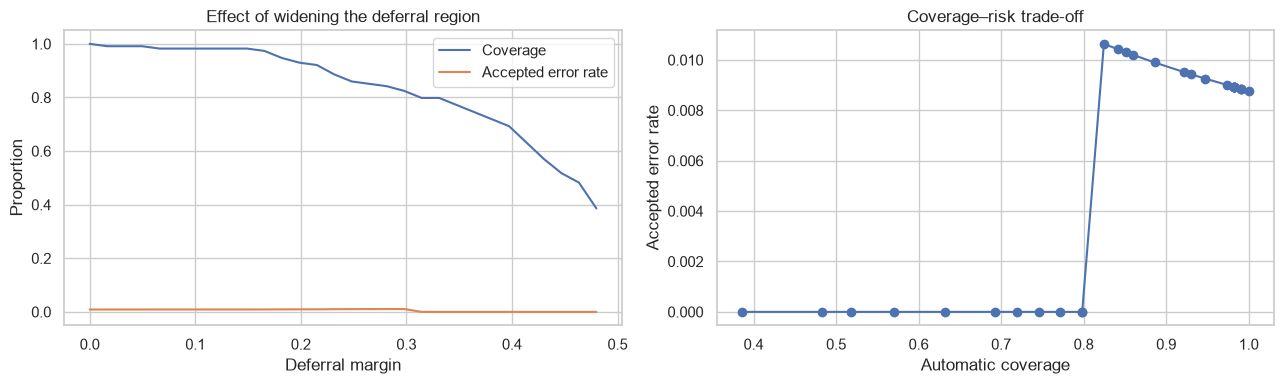

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(validation_selective_df["margin"], validation_selective_df["coverage"], label="Coverage")
axes[0].plot(validation_selective_df["margin"], validation_selective_df["accepted_error_rate"],
             label="Accepted error rate")
axes[0].set(title="Effect of widening the deferral region", xlabel="Deferral margin", ylabel="Proportion")
axes[0].legend()

axes[1].plot(validation_selective_df["coverage"],
             validation_selective_df["accepted_error_rate"], marker="o")
axes[1].set(title="Coverage–risk trade-off", xlabel="Automatic coverage", ylabel="Accepted error rate")

plt.tight_layout()
plt.show()

In [16]:
minimum_coverage = 0.70
eligible_policies = validation_selective_df[
    validation_selective_df["coverage"] >= minimum_coverage
]

selected_policy = eligible_policies.sort_values(
    ["accepted_error_rate", "false_negatives", "coverage"],
    ascending=[True, True, False]
).iloc[0]

selected_margin = float(selected_policy["margin"])
test_selective = selective_metrics(
    y_test, test_probability, selected_threshold, selected_margin
)

display(selected_policy.to_frame("validation_policy").round(3))
display(pd.Series(test_selective, name="test_policy").to_frame().round(3))

,validation_policy
margin,0.314
lower_threshold,0.196
upper_threshold,0.824
coverage,0.798
deferred_cases,23.000
accepted_error_rate,0.000
false_positives,0.000
false_negatives,0.000
accepted_sensitivity,1.000
deferred_malignant,9.000


,test_policy
margin,0.314
lower_threshold,0.196
upper_threshold,0.824
coverage,0.789
deferred_cases,24.000
accepted_error_rate,0.011
false_positives,0.000
false_negatives,1.000
accepted_sensitivity,0.963
deferred_malignant,15.000


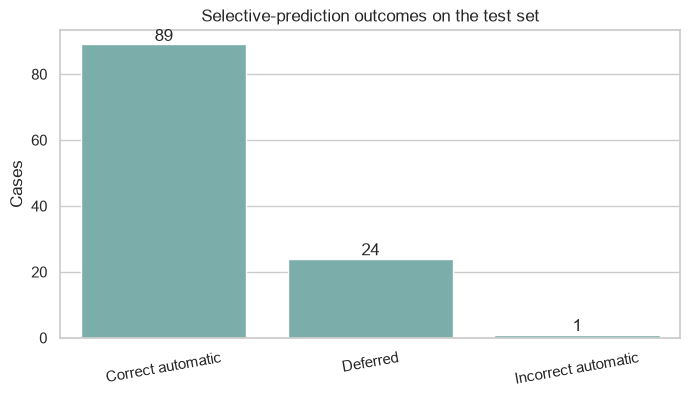

In [17]:
lower_threshold = test_selective["lower_threshold"]
upper_threshold = test_selective["upper_threshold"]

accepted = (test_probability <= lower_threshold) | (test_probability >= upper_threshold)
selective_prediction = (test_probability >= upper_threshold).astype(int)

case_status = np.where(
    ~accepted,
    "Deferred",
    np.where(selective_prediction == np.asarray(y_test), "Correct automatic", "Incorrect automatic")
)

status_counts = pd.Series(case_status).value_counts()

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=status_counts.index, y=status_counts.values, color="#72b7b2")
ax.bar_label(ax.containers[0])
plt.title("Selective-prediction outcomes on the test set")
plt.ylabel("Cases")
plt.xlabel("")
plt.xticks(rotation=10)
plt.show()

### Selective prediction 

The validation procedure selected a deferral margin of **0.314**, producing:

- lower threshold: **0.196**;
- upper threshold: **0.824**;
- validation coverage: **79.8%**;
- deferred validation cases: **23**;
- validation accepted error rate: **0%**.

On the test set, the policy automatically classified **90 of 114 cases**, giving coverage of **78.9%**, while 24 cases were deferred.

Among the 90 automatically classified cases:

- 89 were correct;
- one was incorrect;
- accepted error rate was **1.1%**;
- false positives were **0**;
- false negatives were **1**;
- accepted malignant sensitivity was **96.3%**.

Fifteen of the 24 deferred cases were malignant. This is desirable from a triage perspective because many difficult malignant cases were sent for review instead of receiving an automatic benign decision.

Compared with the ordinary classifier, deferral reduced automatic errors from three to one, but required expert review for 21.1% of cases. It did not eliminate all risk: one malignant case still received an automatic benign classification.

The perfect validation result did not fully transfer to the test set, illustrating why selective policies must be assessed on independent data rather than judged only from the subset used to choose their boundaries.

## 7. Inspect uncertain cases

Cases near the cost-sensitive decision threshold are the most ambiguous. These observations are not necessarily model errors; their measurements may genuinely overlap the malignant and benign distributions.

In [18]:
review_df = X_test.copy()
review_df["actual_class"] = y_test.map({0: "Benign", 1: "Malignant"})
review_df["malignant_probability"] = test_probability
review_df["distance_to_threshold"] = abs(test_probability - selected_threshold)

review_df["system_decision"] = np.select(
    [
        test_probability <= lower_threshold,
        test_probability >= upper_threshold
    ],
    ["Auto benign", "Auto malignant"],
    default="Defer"
)

review_columns = [
    "actual_class", "system_decision", "malignant_probability",
    "mean radius", "mean texture", "mean concavity",
    "worst radius", "worst texture", "worst concavity"
]

review_df.sort_values("distance_to_threshold")[review_columns].head(12).round(3)

,actual_class,system_decision,malignant_probability,mean radius,mean texture,mean concavity,worst radius,worst texture,worst concavity
99,Malignant,Defer,0.516,14.42,19.77,0.094,16.33,30.86,0.319
455,Benign,Defer,0.496,13.38,30.72,0.028,15.05,41.61,0.070
39,Malignant,Defer,0.548,13.48,20.82,0.106,15.53,26.02,0.503
190,Malignant,Defer,0.427,14.22,23.12,0.198,15.74,37.18,0.849
86,Malignant,Defer,0.612,14.48,21.46,0.120,16.21,29.25,0.335
5,Malignant,Defer,0.630,12.45,15.70,0.158,15.47,23.75,0.536
456,Benign,Defer,0.383,11.63,29.29,0.072,13.12,38.81,0.292
205,Malignant,Defer,0.374,15.12,16.68,0.076,17.77,20.24,0.333
385,Malignant,Defer,0.652,14.60,23.29,0.084,15.79,31.71,0.268
14,Malignant,Defer,0.679,13.73,22.61,0.213,15.03,32.01,0.694


## 8. Permutation importance

this section measures how much test ROC-AUC decreases when one feature is randomly shuffled.

A large decrease indicates that the fitted model depends strongly on that feature. Because many tumour measurements are highly correlated, importance may be divided between related variables.

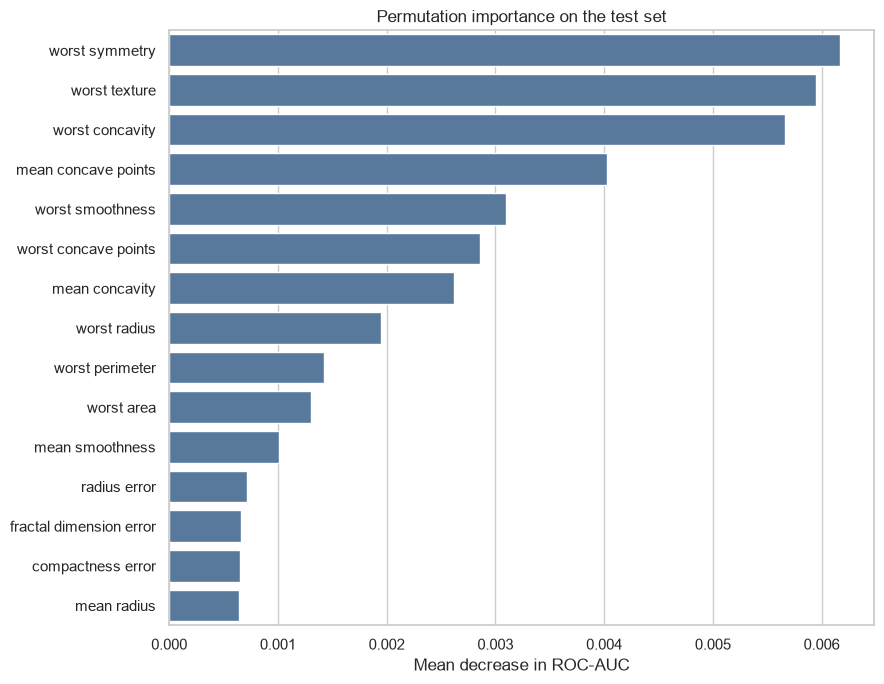

,feature,importance_mean,importance_std
28,worst symmetry,0.0062,0.0021
21,worst texture,0.0060,0.0037
26,worst concavity,0.0057,0.0020
7,mean concave points,0.0040,0.0029
24,worst smoothness,0.0031,0.0016
27,worst concave points,0.0029,0.0017
6,mean concavity,0.0026,0.0019
20,worst radius,0.0020,0.0021
22,worst perimeter,0.0014,0.0016
23,worst area,0.0013,0.0018


In [19]:
importance = permutation_importance(
    selected_model, X_test, y_test,
    scoring="roc_auc", n_repeats=30,
    random_state=RANDOM_STATE, n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std
}).sort_values("importance_mean", ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(data=importance_df, x="importance_mean", y="feature", color="#4c78a8")
plt.title("Permutation importance on the test set")
plt.xlabel("Mean decrease in ROC-AUC")
plt.ylabel("")
plt.tight_layout()
plt.show()

importance_df.round(4)

### Uncertainty and featureimportance 

The observations nearest the 0.51 decision threshold contain both benign and malignant cases. Their malignant probabilities range from approximately 0.33 to 0.69, placing all of them inside the selected deferral region.

These cases have overlapping measurements. Mean radius ranges from approximately 11.63 to 16.26, while worst radius ranges from 13.12 to 17.77. Some malignant cases have high concavity, while others have values that overlap substantially with benign observations. This demonstrates why no single measurement can reliably resolve every case.

The most important features according to test-set permutation importance are:

1. worst symmetry;
2. worst texture;
3. worst concavity;
4. mean concave points;
5. worst smoothness;
6. worst concave points;
7. mean concavity.

Most importance values are numerically small because the model's ROC-AUC is already close to its maximum and many predictors contain overlapping information. When one correlated feature is shuffled, related features can partially replace it, reducing the apparent importance of that individual variable.

Permutation importance should therefore be interpreted as dependence of this fitted model on each feature, not as clinical importance or causal evidence. The estimates are also uncertain because they were calculated from a test set containing only 114 observations.